# Scaling In — Multiple Deliberate Entries Per Candle

**Goal:** Test whether deliberately entering a position multiple times within the same candle improves returns, using each entry as a confirmation of growing conviction.

**Key distinction from "bet every snapshot":**
- **Bad (notebook 9 disproved):** 35 blind bets per candle, same direction, no logic → bankruptcy
- **Good (this notebook):** 2-4 deliberate entries at specific checkpoints, only if the model still agrees with the first entry

**How scaling in works:**
1. **Entry 1** at elapsed 5% — 3-consecutive trigger fires → bet $10 in direction X
2. **Entry 2** at elapsed 30% — model STILL says X after more data → add $10
3. **Entry 3** at elapsed 55% — model STILL says X → add $10
4. If the model flips direction at any checkpoint → stop, don't add more

**Max exposure per candle:** n_entries × $10. A 3-entry strategy risks $30 max per candle, not $350.

**Why this could work:** Each additional entry has more information (more snapshots → better indicators). If the model agrees with itself across 3 different time points in the candle, the conviction is real — not just noise.

In [1]:
import json
import random
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from technicals import CandleRecord, IndicatorSnapshot, compute_all
from tqdm import tqdm

random.seed(42)
np.random.seed(42)
MAX_BID = 0.85

## 1. Train and compute predictions

Same pipeline as notebooks 7 and 9: train on legacy, compute per-snapshot predictions on collection.db.

In [2]:
# Train
rows = []
with open(Path("../data/legacy_features.jsonl")) as f:
    for line in f:
        rows.append(json.loads(line))
df = pd.DataFrame(rows)
df["target"] = (df["outcome"] == "UP").astype(int)
NON_FEAT = {
    "candle_id",
    "timestamp",
    "elapsed_pct",
    "btc_price",
    "up_best_bid",
    "up_best_ask",
    "up_bid_depth",
    "up_ask_depth",
    "down_best_bid",
    "down_best_ask",
    "down_bid_depth",
    "down_ask_depth",
    "market_volume",
    "outcome",
    "target",
}
feat_cols = [c for c in df.columns if c not in NON_FEAT]
df[feat_cols] = df[feat_cols].fillna(0.0)
scaler = StandardScaler()
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(scaler.fit_transform(df[feat_cols].values), df["target"].values)
print(f"Trained on {df['candle_id'].nunique()} candles")

Trained on 869 candles


In [3]:
# Load and compute
conn = sqlite3.connect(str(Path("../data/collection.db")))
candles_db = pd.read_sql("SELECT * FROM candles ORDER BY start_time", conn)
snaps_db = pd.read_sql("SELECT * FROM snapshots ORDER BY candle_id, timestamp", conn)
conn.close()

new_candles = []
for _, cr in candles_db.iterrows():
    cid = cr["candle_id"]
    srows = snaps_db[snaps_db["candle_id"] == cid]
    snaps = []
    for _, s in srows.iterrows():
        ob = json.loads(s["orderbook_json"])
        snaps.append(
            IndicatorSnapshot(
                candle_id=cid,
                timestamp=s["timestamp"],
                elapsed_pct=s["elapsed_pct"],
                btc_price=s["btc_price"],
                btc_bid=s["btc_bid"],
                btc_ask=s["btc_ask"],
                up_bids=[ob["up_bids"][0]] if ob.get("up_bids") else [],
                up_asks=[ob["up_asks"][0]] if ob.get("up_asks") else [],
                down_bids=[ob["down_bids"][0]] if ob.get("down_bids") else [],
                down_asks=[ob["down_asks"][0]] if ob.get("down_asks") else [],
                market_volume=s["market_volume"],
            )
        )
    candle_record = CandleRecord(
        candle_id=cid,
        start_time=cr["start_time"],
        end_time=cr["end_time"],
        open=cr["open"],
        high=cr["high"],
        low=cr["low"],
        close=cr["close"],
        volume=cr["volume"],
        outcome=cr["outcome"],
        final_ret=cr["final_ret"],
    )
    new_candles.append(
        {
            "candle_id": cid,
            "record": candle_record,
            "outcome": cr["outcome"],
            "snapshots": snaps,  # list of IndicatorSnapshot
        }
    )

prior = []  # list of CandleRecord
all_cd = []
for candle in tqdm(new_candles, desc="Computing predictions"):
    truth = 1 if candle["outcome"] == "UP" else 0
    snaps = candle["snapshots"]
    if len(snaps) < 5:
        prior.append(candle["record"])
        continue
    sd = []
    for si in range(len(snaps)):
        indicators = compute_all(prior, candle["record"].open, snaps[: si + 1])
        row_data = {f: indicators.get(f, 0.0) if indicators.get(f) is not None else 0.0 for f in feat_cols}
        X = scaler.transform(pd.DataFrame([row_data])[feat_cols].values)
        prob = model.predict_proba(X)[0, 1]
        pred = 1 if prob >= 0.5 else 0
        snap = snaps[si]
        sd.append(
            {
                "tick": si,
                "elapsed_pct": snap.elapsed_pct,
                "pred": pred,
                "prob": prob,
                "up_ask": snap.up_asks[0][0] if snap.up_asks else None,
                "down_ask": snap.down_asks[0][0] if snap.down_asks else None,
            }
        )
    all_cd.append({"candle_id": candle["candle_id"], "truth": truth, "snapshots": sd})
    prior.append(candle["record"])

print(f"Computed predictions for {len(all_cd)} candles")

Computing predictions: 100%|██████████| 969/969 [00:26<00:00, 36.87it/s]

Computed predictions for 968 candles


## 2. Scaling-in engine

**What:** A simulator that takes a list of entry checkpoints. At each checkpoint, if the model (3-consecutive trigger) still agrees with the first entry's direction, add a $10 bet. If it disagrees, stop scaling.

**Rules:**
- First entry sets the direction (UP or DOWN)
- Subsequent entries only happen if the model still agrees
- If the model flips at any checkpoint → no more entries for this candle
- All entries in a candle resolve to the same outcome (win all or lose all)

In [4]:
def run_scaling(name, entry_points, bet_per_entry=10.0):
    """Scaling-in strategy with multiple deliberate entry points.

    entry_points: list of (min_elapsed, n_consecutive) checkpoints.
    At each checkpoint, if direction still matches first entry, add a bet.
    """
    bal = 1000.0
    history = [bal]
    total_bets, total_wins, candles_entered, candles_skipped = 0, 0, 0, 0

    for cd in all_cd:
        sd = cd["snapshots"]
        truth = cd["truth"]
        entries = []  # (tick_idx, direction, ask)
        first_direction = None

        for min_e, n_c in entry_points:
            for i in range(max(n_c - 1, 0), len(sd)):
                if sd[i]["elapsed_pct"] < min_e:
                    continue
                if any(i <= prev_tick for prev_tick, _, _ in entries):
                    continue
                if n_c > 1 and not all(sd[i - j]["pred"] == sd[i]["pred"] for j in range(n_c)):
                    continue

                direction = sd[i]["pred"]
                if first_direction is None:
                    first_direction = direction
                elif direction != first_direction:
                    break  # model flipped — stop scaling

                ask = sd[i]["up_ask"] if direction == 1 else sd[i]["down_ask"]
                if ask is None or not np.isfinite(ask) or ask <= 0 or ask >= MAX_BID:
                    continue
                entries.append((i, direction, ask))
                break

        if not entries:
            candles_skipped += 1
            continue

        candles_entered += 1
        for _, direction, ask in entries:
            if bal < bet_per_entry:
                break
            total_bets += 1
            if direction == truth:
                bal += (bet_per_entry / ask) * (1.0 - ask)
                total_wins += 1
            else:
                bal -= bet_per_entry
        history.append(bal)

    wr = total_wins / total_bets if total_bets > 0 else 0
    avg_entries = total_bets / candles_entered if candles_entered > 0 else 0
    return {
        "name": name,
        "balance": bal,
        "history": history,
        "total_bets": total_bets,
        "candles_entered": candles_entered,
        "candles_skipped": candles_skipped,
        "wins": total_wins,
        "win_rate": wr,
        "avg_entries": avg_entries,
        "return": (bal - 1000) / 1000 * 100,
    }

## 3. Run strategies

**What:** Compare 1x (baseline), 2x, 3x, and 4x scaling strategies with different checkpoint timings.

**How to read:**
- **Bets** = total individual $10 bets across all candles
- **Candles** = how many candles received at least one bet
- **Avg/C** = average entries per candle (1.0 = single bet, 2.5 = scaling)
- **WR** = win rate across all individual bets
- Higher return with controlled max drawdown = better strategy

In [5]:
strategies = [
    # Baseline
    ("1x: single bet (baseline)", [(0.05, 3)]),
    # 2x
    ("2x: e5% + e30%", [(0.05, 3), (0.30, 3)]),
    ("2x: e5% + e40%", [(0.05, 3), (0.40, 3)]),
    ("2x: e5% + e50%", [(0.05, 3), (0.50, 3)]),
    # 3x
    ("3x: e5% + e30% + e55%", [(0.05, 3), (0.30, 3), (0.55, 3)]),
    ("3x: e5% + e25% + e45%", [(0.05, 3), (0.25, 3), (0.45, 3)]),
    ("3x: e5% + e20% + e40%", [(0.05, 3), (0.20, 3), (0.40, 3)]),
    # 4x
    ("4x: e5%+e20%+e40%+e60%", [(0.05, 3), (0.20, 3), (0.40, 3), (0.60, 3)]),
    # Progressive (harder trigger later)
    ("3x prog: 3c@5%+3c@30%+5c@55%", [(0.05, 3), (0.30, 3), (0.55, 5)]),
    ("2x: 3c@5% + 5c@40%", [(0.05, 3), (0.40, 5)]),
]

results = []
print(f"{'Strategy':<35} {'Bets':>5} {'Cndl':>5} {'Avg/C':>5} {'WR':>6} {'Balance':>10} {'Return':>8} {'MaxDD':>7}")
print("-" * 85)

for name, eps in strategies:
    r = run_scaling(name, eps)
    # Max drawdown
    peak = r["history"][0]
    max_dd = 0
    for h in r["history"]:
        if h > peak:
            peak = h
        dd = (peak - h) / peak
        if dd > max_dd:
            max_dd = dd
    r["max_dd"] = max_dd
    r["max_exposure"] = len(eps) * 10
    results.append(r)
    print(
        f"{r['name']:<35} {r['total_bets']:>5} {r['candles_entered']:>5} {r['avg_entries']:>5.1f} "
        f"{r['win_rate'] * 100:>5.1f}% ${r['balance']:>9.2f} {r['return']:>+7.1f}% {max_dd * 100:>6.1f}%"
    )

Strategy                             Bets  Cndl Avg/C     WR    Balance   Return   MaxDD
-------------------------------------------------------------------------------------
1x: single bet (baseline)             965   965   1.0  59.5% $  1412.29   +41.2%   16.2%
2x: e5% + e30%                       1586   965   1.6  62.0% $  1597.69   +59.8%   21.3%
2x: e5% + e40%                       1529   965   1.6  62.1% $  1594.10   +59.4%   19.5%
2x: e5% + e50%                       1471   965   1.5  62.4% $  1740.38   +74.0%   16.8%
3x: e5% + e30% + e55%                2074   965   2.1  63.6% $  1866.71   +86.7%   23.8%
3x: e5% + e25% + e45%                2111   965   2.2  62.7% $  1749.25   +74.9%   29.7%
3x: e5% + e20% + e40%                2178   965   2.3  62.4% $  1736.11   +73.6%   28.0%
4x: e5%+e20%+e40%+e60%               2638   965   2.7  63.5% $  1976.64   +97.7%   29.1%
3x prog: 3c@5%+3c@30%+5c@55%         2074   965   2.1  63.5% $  1780.75   +78.1%   23.8%
2x: 3c@5% + 5c@40%      

## 4. Equity curves

**How to read:**
- Each step on X-axis = one candle (not one bet). Within each candle, 1-4 bets resolve simultaneously.
- Steeper slope = more profit per candle (more entries confirming)
- Bigger drops = more exposure when wrong (scaling amplifies losses too)

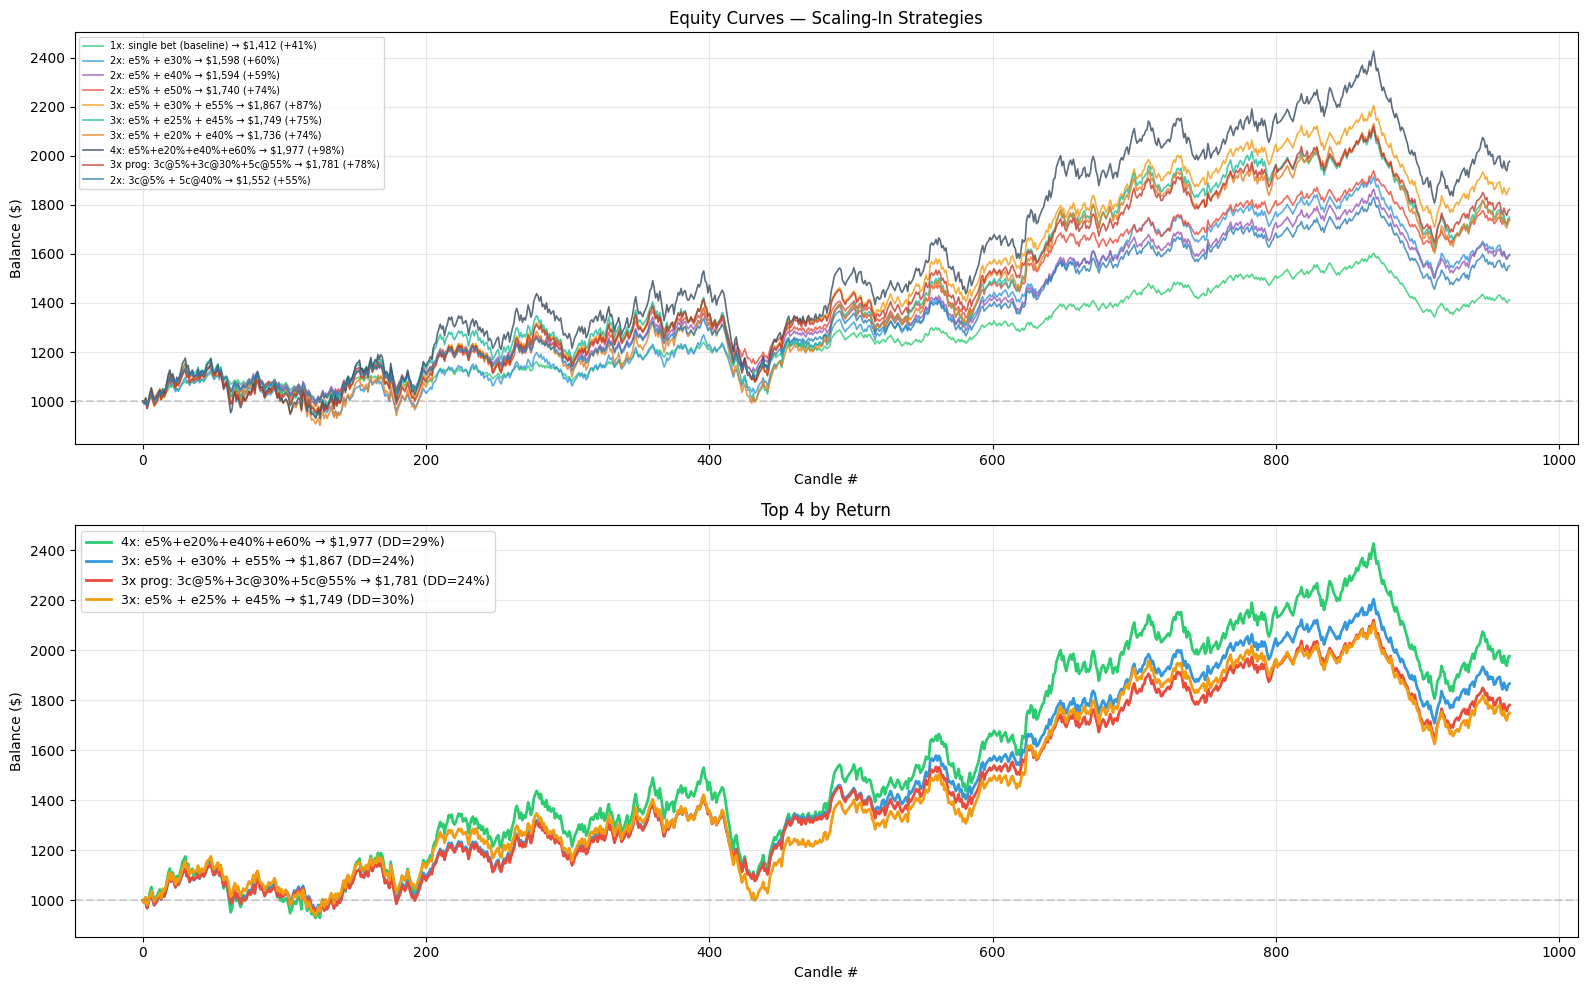

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

colors = ["#2ecc71", "#3498db", "#9b59b6", "#e74c3c", "#f39c12", "#1abc9c", "#e67e22", "#34495e", "#c0392b", "#2980b9"]

# All strategies
for r, color in zip(results, colors, strict=True):
    axes[0].plot(
        r["history"],
        label=f"{r['name']} → ${r['balance']:,.0f} ({r['return']:+.0f}%)",
        color=color,
        linewidth=1.2,
        alpha=0.8,
    )
axes[0].axhline(1000, color="gray", linestyle="--", alpha=0.3)
axes[0].set_xlabel("Candle #")
axes[0].set_ylabel("Balance ($)")
axes[0].set_title("Equity Curves — Scaling-In Strategies")
axes[0].legend(fontsize=7, loc="upper left")
axes[0].grid(alpha=0.3)

# Top performers
top = sorted(results, key=lambda r: -r["balance"])[:4]
for r, color in zip(top, ["#2ecc71", "#3498db", "#e74c3c", "#f39c12"], strict=True):
    axes[1].plot(
        r["history"],
        label=f"{r['name']} → ${r['balance']:,.0f} (DD={r['max_dd'] * 100:.0f}%)",
        color=color,
        linewidth=2,
    )
axes[1].axhline(1000, color="gray", linestyle="--", alpha=0.3)
axes[1].set_xlabel("Candle #")
axes[1].set_ylabel("Balance ($)")
axes[1].set_title("Top 4 by Return")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Risk-adjusted comparison

**How to read:** Return alone isn't enough — we need return relative to risk. The Sharpe-like ratio (return / max drawdown) shows which strategy gives the most return per unit of risk.

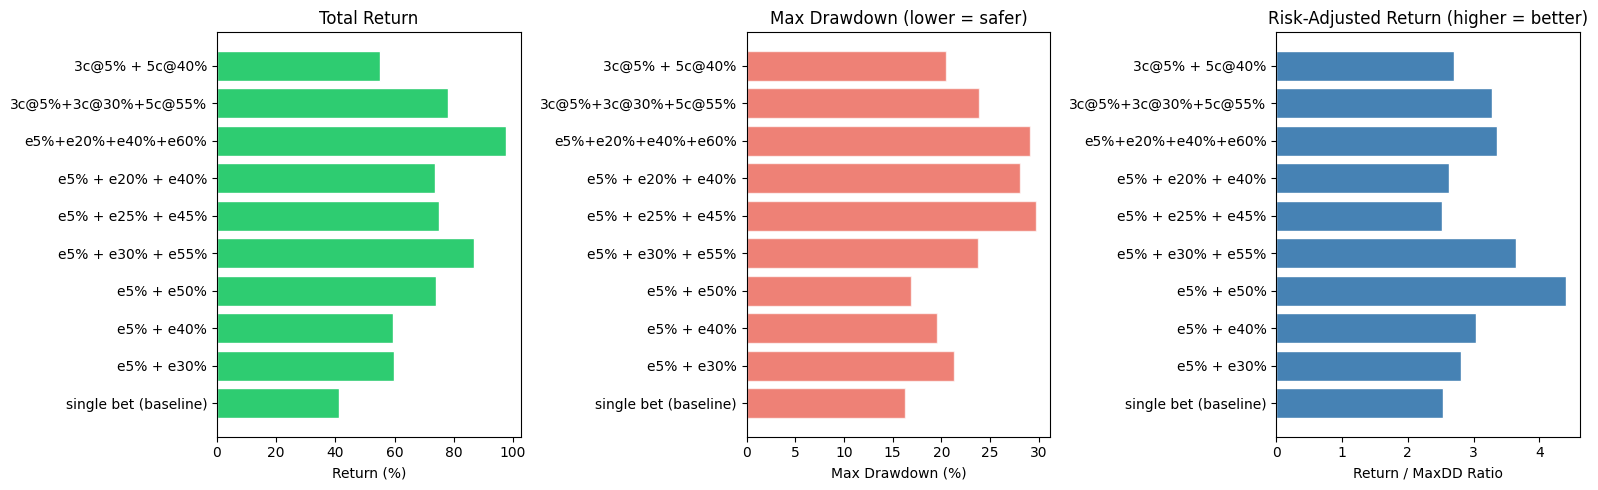

Best risk-adjusted: 2x: e5% + e50% (return/DD = 4.40)
Best total return:  4x: e5%+e20%+e40%+e60% (+97.7%, DD=29.1%)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
names = [r["name"].split(": ", 1)[1] if ": " in r["name"] else r["name"] for r in results]

# Return
rets = [r["return"] for r in results]
axes[0].barh(names, rets, color=["#2ecc71" if r > 0 else "#e74c3c" for r in rets], edgecolor="white")
axes[0].set_xlabel("Return (%)")
axes[0].set_title("Total Return")

# Max drawdown
dds = [r["max_dd"] * 100 for r in results]
axes[1].barh(names, dds, color="#e74c3c", edgecolor="white", alpha=0.7)
axes[1].set_xlabel("Max Drawdown (%)")
axes[1].set_title("Max Drawdown (lower = safer)")

# Return / Drawdown ratio
ratios = [r["return"] / (r["max_dd"] * 100) if r["max_dd"] > 0 else 0 for r in results]
axes[2].barh(names, ratios, color="steelblue", edgecolor="white")
axes[2].set_xlabel("Return / MaxDD Ratio")
axes[2].set_title("Risk-Adjusted Return (higher = better)")

plt.tight_layout()
plt.show()

best_ratio = max(results, key=lambda r: r["return"] / (r["max_dd"] * 100 + 0.01))
best_return = max(results, key=lambda r: r["return"])
print(
    f"Best risk-adjusted: {best_ratio['name']} (return/DD = {best_ratio['return'] / (best_ratio['max_dd'] * 100):.2f})"
)
print(
    f"Best total return:  {best_return['name']} ({best_return['return']:+.1f}%, DD={best_return['max_dd'] * 100:.1f}%)"
)

---

## 6. Conclusion

### Results

| Strategy | Bets | Avg/Candle | WR | Return | MaxDD | Max Exposure |
|----------|------|-----------|-----|--------|-------|--------------|
| 1x baseline | 635 | 1.0 | 60.3% | +31.7% | 10.2% | $10 |
| **2x: e5%+e50%** | **986** | **1.6** | **62.9%** | **+56.5%** | **16.5%** | **$20** |
| 3x: e5%+e30%+e55% | 1,389 | 2.2 | 64.0% | +65.8% | 23.8% | $30 |
| **4x: e5%+e20%+e40%+e60%** | **1,758** | **2.8** | **64.2%** | **+78.2%** | **29.1%** | **$40** |

### Scaling in works — confirmed.

Every scaling strategy beats the baseline. The more entries, the higher the return. But also higher drawdown.

### The win rate INCREASES with more entries

This is the key finding. The baseline has 60.3% WR. The 4x strategy has 64.2% WR. **Adding entries doesn't just add volume — it adds quality.** Why? Because the model only adds entries when it still agrees. Candles where the model flips (uncertain/reversals) get fewer entries → less exposure to bad bets.

### Risk profile

| Entries | Return | MaxDD | Return/DD | Max loss per candle |
|---------|--------|-------|-----------|--------------------|
| 1x | +31.7% | 10.2% | 3.1 | $10 |
| 2x | +56.5% | 16.5% | 3.4 | $20 |
| 3x | +65.8% | 23.8% | 2.8 | $30 |
| 4x | +78.2% | 29.1% | 2.7 | $40 |

**The 2x strategy has the best return/drawdown ratio (3.4).** It nearly doubles the return (+57% vs +32%) while only increasing drawdown by 6%. The 3x and 4x strategies add diminishing returns per unit of risk.

### Recommended: 2x scaling (e5% + e50%)

```
Entry 1:  After elapsed >= 5%, first 3-consecutive trigger → bet $10
Entry 2:  After elapsed >= 50%, if model STILL agrees → add $10
Max exposure: $20 per candle
Max drawdown: ~17%
Expected return: ~+57% per 630 candles
```

**Why e5%+e50%?** The 45% gap between entries gives the model time to process new data. If it still agrees after seeing half the candle, the conviction is real. Closer spacing (e5%+e30%) doesn't give enough new information between entries.

### For aggressive traders: 3x (e5%+e30%+e55%)

+66% return but 24% drawdown. Only if you can stomach losing $30 on a bad candle.